In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import umap

/dev/shm/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-3u8bufcg because there was an issue with the default path (/dev/shm/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/storage/brno12-cerit/home/kratka/envs/esm2_screening/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
toxin_db = np.load("data/embeddings/toxin_embeddings_large.npz")
neutral_db = np.load("data/embeddings/neutral_embeddings_large.npz")
scale_db = np.load("data/embeddings/identity_scale_toxin.npz")
critical_db = np.load("data/embeddings/critical_toxins_batch.npz")
critical_generated_db = np.load("data/embeddings/generated_critical_toxins.npz")

In [3]:
print(toxin_db.files)  # show what arrays are in the toxin database
print(neutral_db.files)  # show what arrays are in the neutral database

['names', 'accessions', 'embeddings']
['names', 'accessions', 'embeddings']


In [6]:
X_toxin = toxin_db["embeddings"]
X_neutral = neutral_db["embeddings"]
X_identity_scale = scale_db["embeddings"]
X_critical = critical_db["embeddings"]
X_critical_generated = critical_generated_db["embeddings"]
names_toxin = toxin_db["names"]
names_neutral = neutral_db["names"]
names_identity_scale = scale_db["names"]
names_critical = critical_db["names"]
names_critical_generated = critical_generated_db["names"]

X_combined = np.vstack((X_toxin, X_neutral))
X_norm = normalize(X_combined, norm='l2')

In [5]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_combined)

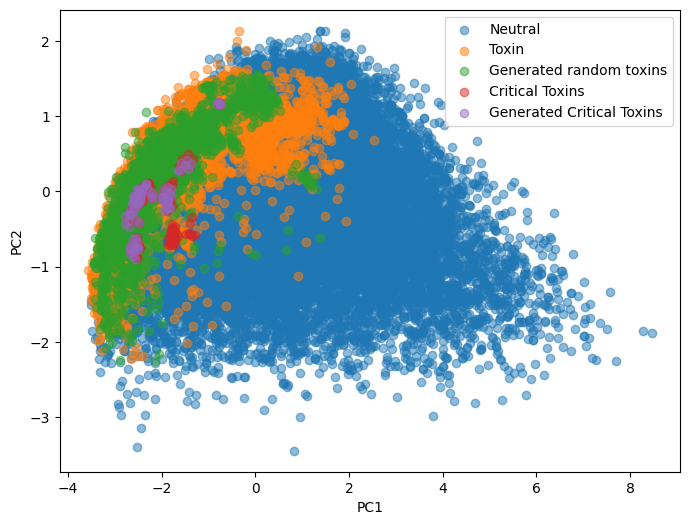

In [58]:
# Project all datasets onto the learned PCA space
X_pca_toxin = pca.transform(X_toxin)
X_pca_neutral = pca.transform(X_neutral)
X_pca_identity_scale = pca.transform(X_identity_scale)
X_pca_critical = pca.transform(X_critical)
X_pca_critical_generated = pca.transform(X_critical_generated)

# Quick 2D plot
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_neutral[:, 0], X_pca_neutral[:, 1], label="Neutral", alpha=0.5)
plt.scatter(X_pca_toxin[:, 0], X_pca_toxin[:, 1], label="Toxin", alpha=0.5)
plt.scatter(X_pca_identity_scale[:, 0], X_pca_identity_scale[:, 1], label="Generated random toxins", alpha=0.5)
plt.scatter(X_pca_critical[:, 0], X_pca_critical[:, 1], label="Critical Toxins", alpha=0.5)
plt.scatter(X_pca_critical_generated[:, 0], X_pca_critical_generated[:, 1], label="Generated Critical Toxins", alpha=0.5)   
plt.legend()
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


In [23]:
pca_norm = PCA(n_components=50)
X_pca_norm = pca_norm.fit_transform(X_norm)

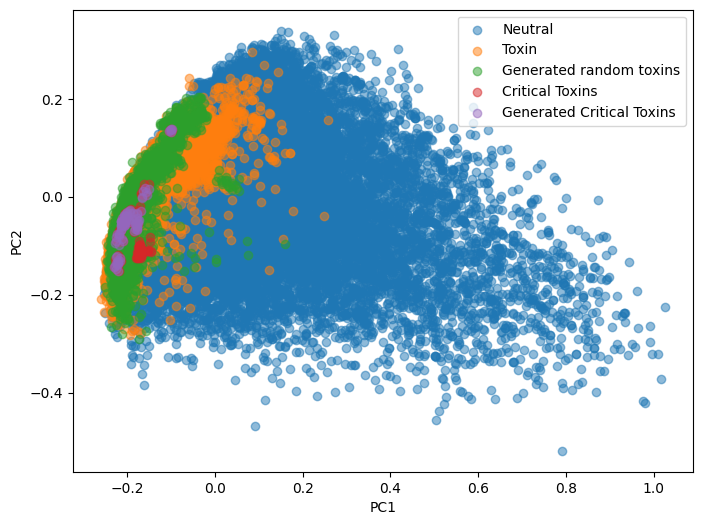

<Figure size 640x480 with 0 Axes>

In [57]:
# Project all datasets onto the learned PCA space
X_pca_norm_toxin = pca_norm.transform(normalize(X_toxin, norm='l2'))
X_pca_norm_neutral = pca_norm.transform(normalize(X_neutral, norm='l2'))
X_pca_norm_identity_scale = pca_norm.transform(normalize(X_identity_scale, norm='l2'))
X_pca_norm_critical = pca_norm.transform(normalize(X_critical, norm='l2'))
X_pca_norm_critical_generated = pca_norm.transform(normalize(X_critical_generated, norm='l2'))

# Quick 2D plot
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_norm_neutral[:, 0], X_pca_norm_neutral[:, 1], label="Neutral", alpha=0.5)
plt.scatter(X_pca_norm_toxin[:, 0], X_pca_norm_toxin[:, 1], label="Toxin", alpha=0.5)
plt.scatter(X_pca_norm_identity_scale[:, 0], X_pca_norm_identity_scale[:, 1], label="Generated random toxins", alpha=0.5)
plt.scatter(X_pca_norm_critical[:, 0], X_pca_norm_critical[:, 1], label="Critical Toxins", alpha=0.5)
plt.scatter(X_pca_norm_critical_generated[:, 0], X_pca_norm_critical_generated[:, 1], label="Generated Critical Toxins", alpha=0.5)
plt.legend()
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()
plt.savefig("data/fig/pca_projection.svg", dpi=300)

The normalization does not seem to have a large effect.

/auto/brno12-cerit/nfs4/home/kratka/envs/esm2_screening/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


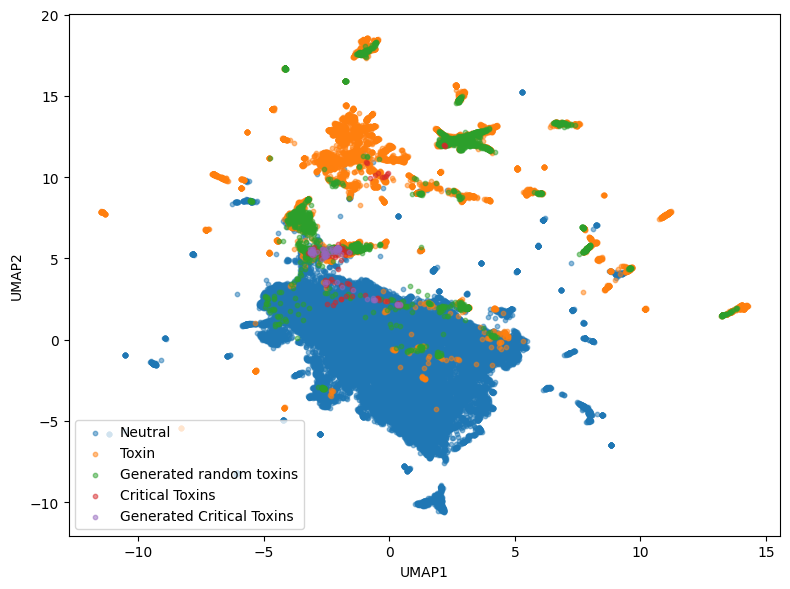

<Figure size 640x480 with 0 Axes>

In [59]:
# Fit UMAP on PCA-reduced combined data
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)

# project each dataset separately
X_umap_toxin = reducer.transform(X_pca_toxin)
X_umap_neutral = reducer.transform(X_pca_neutral)
X_umap_identity_scale = reducer.transform(X_pca_identity_scale)
X_umap_critical = reducer.transform(X_pca_critical)
X_umap_critical_generated = reducer.transform(X_pca_critical_generated)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_umap_neutral[:, 0], X_umap_neutral[:, 1], label="Neutral", alpha=0.5, s=10)
ax.scatter(X_umap_toxin[:, 0], X_umap_toxin[:, 1], label="Toxin", alpha=0.5, s=10)
ax.scatter(X_umap_identity_scale[:, 0], X_umap_identity_scale[:, 1], label="Generated random toxins", alpha=0.5, s=10)
ax.scatter(X_umap_critical[:, 0], X_umap_critical[:, 1], label="Critical Toxins", alpha=0.5, s=10)
ax.scatter(X_umap_critical_generated[:, 0], X_umap_critical_generated[:, 1], label="Generated Critical Toxins", alpha=0.5, s=10)    
ax.legend()
ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
plt.tight_layout()
plt.show()
plt.savefig("data/fig/umap_projection.svg")

# Try out similarity search in the embedding space between example generated toxin and the rest of the database. 

In [26]:
example_scale_toxin = X_identity_scale[0] 

s_toxic = X_toxin @ example_scale_toxin
s_neutral = X_neutral @ example_scale_toxin


In [27]:
max_s_toxic = np.max(s_toxic)
max_s_neutral = np.max(s_neutral)
print(f"Max similarity to example scale toxin - Toxin DB: {max_s_toxic:.4f}")
print(f"Max similarity to example scale toxin - Neutral DB: {max_s_neutral:.4f}")

Max similarity to example scale toxin - Toxin DB: 92.0389
Max similarity to example scale toxin - Neutral DB: 90.2489


# Calculate the max similarity difference for all generated toxins 

In [28]:
def calculate_diff(screened, X_toxin, X_neutral):
    s_toxic = X_toxin @ screened
    s_neutral = X_neutral @ screened
    max_s_toxic = np.max(s_toxic)
    max_s_neutral = np.max(s_neutral)
    return max_s_toxic - max_s_neutral

def calculate_similarity(screened, X_toxin, X_neutral):
    s_toxic = X_toxin @ screened
    s_neutral = X_neutral @ screened
    max_s_toxic = np.max(s_toxic)
    max_s_neutral = np.max(s_neutral)
    return max(max_s_toxic, max_s_neutral)

diffs = [calculate_diff(screened, X_toxin, X_neutral) for screened in X_identity_scale]
similarity_to_database = [calculate_similarity(screened, X_toxin, X_neutral) for screened in X_identity_scale]



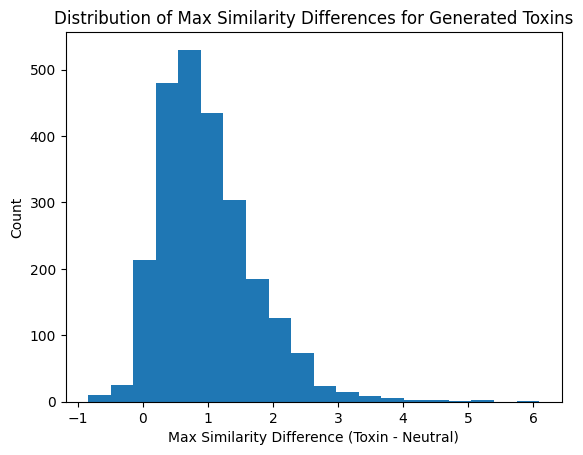

In [ ]:
plt.hist(diffs, bins=20)
plt.xlabel("Max Similarity Difference (Toxin - Neutral)")
plt.ylabel("Count")
plt.title("Distribution of Max Similarity Differences for Generated Toxins")
plt.show()


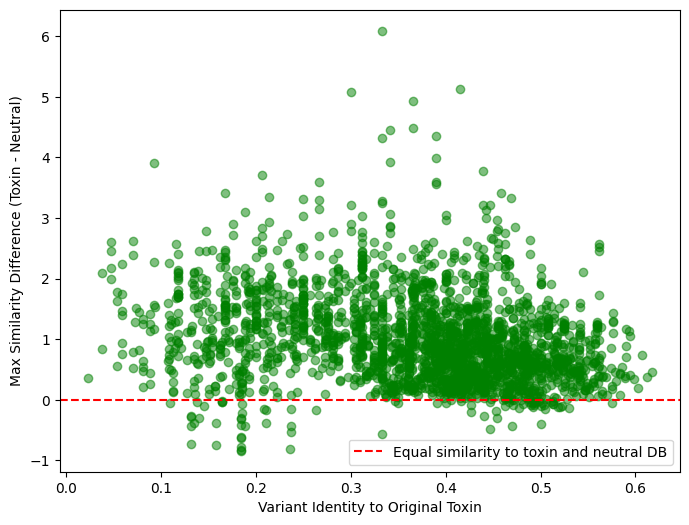

<Figure size 640x480 with 0 Axes>

In [60]:
# split the names of the identity scale toxins to get the variant identity
variant_identity = [name.split("_var")[0].split("_id")[-1] for name in names_identity_scale]
# convert percentage strings to proportions
variant_identity = [float(vid.strip("%")) / 100.0 for vid in variant_identity]

plt.figure(figsize=(8, 6))
plt.scatter(variant_identity, diffs, c="green", alpha=0.5)
plt.xlabel("Variant Identity to Original Toxin")
plt.ylabel("Max Similarity Difference (Toxin - Neutral)")
# add horizontal line at y=0
plt.axhline(0, color='red', linestyle='--', label="Equal similarity to toxin and neutral DB")
plt.legend()
plt.show()
# save svg
plt.savefig("data/fig/similarity_difference_vs_variant_identity.svg")

In [45]:
# how many generated toxins have higher similarity to toxin database than neutral database?
num_better_than_neutral = sum(1 for diff in diffs if diff > 0)
print(f"Number of generated toxins with higher similarity to toxin DB than neutral DB: {num_better_than_neutral} out of {len(diffs)}")

Number of generated toxins with higher similarity to toxin DB than neutral DB: 2361 out of 2440


Variant Identity - Min: 0.02, Max: 0.62, Mean: 0.37


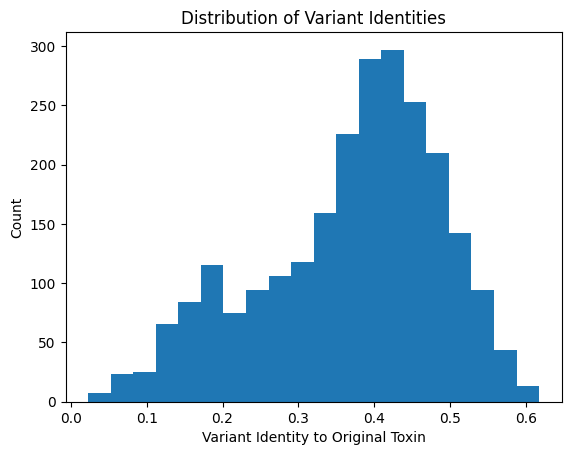

In [31]:
# describe the variant identities (min, max, mean, histogram)
print(f"Variant Identity - Min: {np.min(variant_identity):.2f}, Max: {np.max(variant_identity):.2f}, Mean: {np.mean(variant_identity):.2f}")
plt.hist(variant_identity, bins=20)
plt.xlabel("Variant Identity to Original Toxin")
plt.ylabel("Count")
plt.title("Distribution of Variant Identities")
plt.show()

In toxin variants with identity to the original below 30%, the similarity difference is more scattered, suggesting that the embedding space may not reliably distinguish between toxin and neutral sequences at very low identity levels.

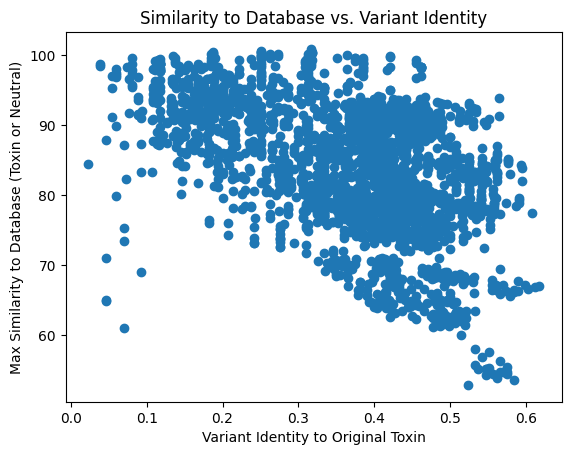

In [32]:
# Similarity to database vs. variant identity
plt.scatter(variant_identity, similarity_to_database)
plt.xlabel("Variant Identity to Original Toxin")
plt.ylabel("Max Similarity to Database (Toxin or Neutral)")
plt.title("Similarity to Database vs. Variant Identity")
plt.show()

The best match similarity to the database (max of toxin and neutral) paradoxically increases at low identity levels. To investigate this, we could analyze whether the low-identity variants still match to the original toxin sequences.

# Find how many original there are in generated toxins

In [7]:
# list of original protein structures
accessions = [name.split("_")[2] for name in names_identity_scale]
accessions_unique = set(accessions)
print(f"Unique original proteins: {len(accessions_unique)}")
# save the accessions to a text file
with open("data/accessions.txt", "w") as f:
    for acc in accessions_unique:
        f.write(f"{acc}\n")

Unique original proteins: 121


In [8]:
# list of original protein structures
accessions = [name.split("_")[2] for name in names_critical_generated]
accessions_unique = set(accessions)
print(f"Unique original proteins: {len(accessions_unique)}")
# save the accessions to a text file
with open("data/accessions.txt", "w") as f:
    for acc in accessions_unique:
        f.write(f"{acc}\n")

Unique original proteins: 6
